# ALGORITHM

Startpeak position of A in data: 988
Startpeak position of B in data: 1207


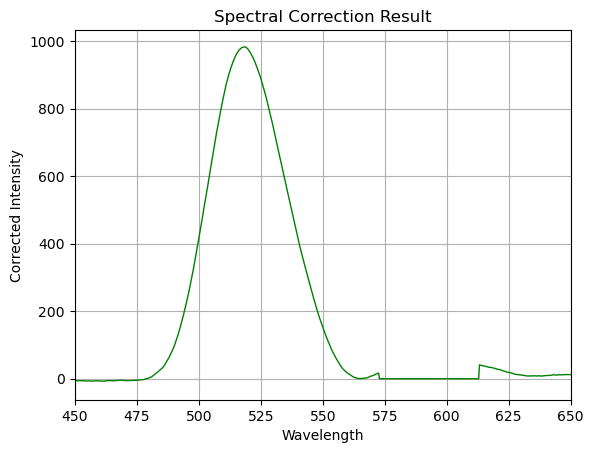

Results saved to: Fixpeaksegment.txt


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import os

# File path where spectrogram of mouse data is located
# Should be the spectrogram with no reference elimination applied
file_path = 'C:/Users/admin/python_project/Flna9_G25(no ref).csv'

# CSV from raw spectrogram data of GCaMP6f is loaded
data = pd.read_csv(file_path, header=None)
Used_table = data.copy()

# Dividing areas for A and B detection range
# Detection range A : range for green biosensor (around 517nm)
# Detection range B : range for red biosensor (around 590nm)
A = Used_table.iloc[820:1073].reset_index(drop=True)
B = Used_table.iloc[1073:2135].reset_index(drop=True)

# Extract Peak for A
# Why? to find out the peak for calculation
# Find the peak for range A, then extract intensities for wavelength +-60nm peak wavelength.
peaks_A, _ = find_peaks(A[1], distance=10)
peak_A_idx = peaks_A[np.argmax(A.iloc[peaks_A, 1])]
start_idx_A = max(peak_A_idx - 60, 0)
end_idx_A = min(peak_A_idx + 60, len(A))
peak_segment_A = A.iloc[start_idx_A:end_idx_A].reset_index(drop=True)

# Find the peak for range B, then extract intensities for wavelength +-60nm peak wavelength.
# This will be the segment for further calculation!
peaks_B, _ = find_peaks(B[1], distance=10)
peak_B_idx = peaks_B[np.argmax(B.iloc[peaks_B, 1])]
start_idx_B = max(peak_B_idx - 60, 0)
end_idx_B = min(peak_B_idx + 60, len(B))
peak_segment_B = B.iloc[start_idx_B:end_idx_B].reset_index(drop=True)

# Absolute index calculation
# THIS data is for LABVIEW Application! Very Important, since Labview operates by using this #!
absolute_start_idx_A = 820 + peak_A_idx
absolute_start_idx_B = 1073 + peak_B_idx
print(f"Startpeak position of A in data: {absolute_start_idx_A}")
print(f"Startpeak position of B in data: {absolute_start_idx_B}")

# Calculating reference using peakSegment A and B
reference_num = peak_segment_A[1] * (peak_segment_B[1] / peak_segment_A[1])
reference_subtract = peak_segment_B[1] - reference_num
reference_subtract[reference_subtract < 0.001] = 0

result_table = pd.DataFrame({
    'VarName1': peak_segment_B[0],
    'VarName2': reference_subtract})

# Applying corrected value to full data for visualizing spectrogram graph
New_result_table = Used_table.copy()
for i in range(len(result_table)):
    idx = New_result_table[0] == result_table.loc[i, 'VarName1']
    New_result_table.loc[idx, 1] = result_table.loc[i, 'VarName2']

# Drawing corrected full spectrogram graph
plt.plot(New_result_table[0], New_result_table[1], color='g', linewidth=1)
plt.xlim([450, 650])
plt.xlabel('Wavelength')
plt.ylabel('Corrected Intensity')
plt.title('Spectral Correction Result')
plt.grid(True)
plt.show()

# Calculation of ratios for two segments (red/green)
Fixpeaksegment = peak_segment_B[1] / peak_segment_A[1]
Fixpeaksegment.replace([np.inf, -np.inf], 0, inplace=True)
Fixpeaksegment = Fixpeaksegment.abs().round(5)

# Save the calculated ratios of the green biosensor for later use
output_file = 'Fixpeaksegment.txt'
Fixpeaksegment.to_csv(output_file, index=False, header=False)
print(f"Results saved to: {output_file}")


### **Calculating ratios from multiple mice**

Now we calculated corrected intesntiy ratio from single mouse.  
But if we want to use it for universal base for algorithm, the ratio should be constant for multiple mice, right?

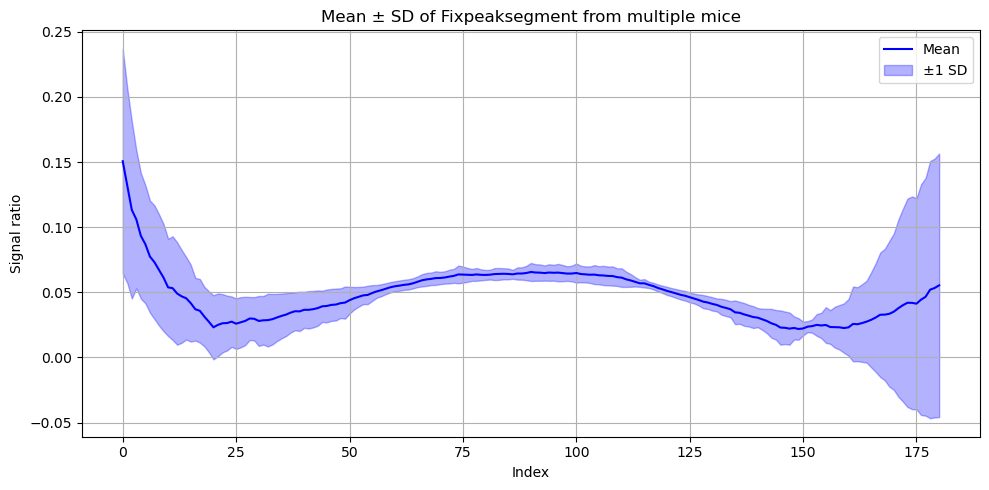

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# Finding every signal ratio files from different mice
# Better than plotting single file name in here :)
all_files = glob.glob("C:/Users/admin/python_project/signal_ratios/Flna*_Fixpeaksegment.csv")

# Loading and adding multiple data into one
data_list = [pd.read_csv(fp, header=None).squeeze() for fp in all_files]
combined_df = pd.concat(data_list, axis=1)
combined_df = combined_df.apply(pd.to_numeric, errors='coerce')

# Calcuation of mean and standard deviation
mean_vals = combined_df.mean(axis=1)
std_vals = combined_df.std(axis=1)
x_vals = np.arange(len(mean_vals))

# Filtering
mean_vals = pd.to_numeric(mean_vals, errors='coerce').astype(np.float64)
std_vals = pd.to_numeric(std_vals, errors='coerce').astype(np.float64)
x_vals = np.array(x_vals, dtype=np.float64)
valid_mask = np.isfinite(mean_vals) & np.isfinite(std_vals)

# Filtered data
x_final = x_vals[valid_mask]
mean_final = mean_vals[valid_mask]
std_final = std_vals[valid_mask]

# Drawing graph
plt.figure(figsize=(10, 5))
plt.plot(x_final, mean_final, label='Mean', color='blue')
plt.fill_between(x_final, mean_final - std_final, mean_final + std_final,
                 color='blue', alpha=0.3, label='±1 SD')
plt.xlabel("Index")
plt.ylabel("Signal ratio")
plt.title("Mean ± SD of Fixpeaksegment from multiple mice")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


As we can see, the ratio from multiple mice are overall stable.  
So this can support our idea that algorithm can be applied to different mice.  

Now, using this fixpeaksegment file, we are goint to applie it to LABVIEW for real-time application.